# CRIC Cervix - deteccao de todas as celulas com YOLO

Notebook sequencial e autonomo para Colab/T4. Ele usa apenas a pasta `cric_cervix`, ignora a classificacao Bethesda e converte cada ponto `nucleus_x, nucleus_y` em uma caixa YOLO de classe unica: `cell`.

A ideia aqui e maximizar mAP para deteccao de celulas, nao classificar normal/anormal.

## 1. Montar Drive e descompactar o dataset

Execute esta celula no Colab. Se a pasta `/content/cric_cervix` ja existir, a descompactacao sera pulada.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from pathlib import Path

# Instala o descompactador usado para abrir o arquivo .rar no Colab.
!apt-get -qq update
!apt-get -qq install -y unrar

# Ajuste estes caminhos se o arquivo estiver em outra pasta do Drive.
arquivo_rar = "/content/drive/MyDrive/CRIC/cric_cervix.rar"
destino = "/content"
dataset_dir = Path(destino) / "cric_cervix"

if dataset_dir.exists():
    print(f"Dataset ja existe em {dataset_dir}. Pulando descompactacao.")
else:
    print(f"Descompactando {arquivo_rar} em {destino}...")
    !unrar x -o+ "{arquivo_rar}" "{destino}"
    print("Descompactacao concluida.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Descompactando /content/drive/MyDrive/CRIC/cric_cervix.rar em /content...

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/CRIC/cric_cervix.rar

Creating    /content/cric_cervix                                      OK
Creating    /content/cric_cervix/classification                       OK
Extracting  /content/cric_cervix/classification/classifications.csv        0%  OK 
Extracting  /content/cric_cervix/classification/classifications.json       0%  OK 
Extracting  /content/cric_cervix/classification/README.md                  0%  OK 
Creating    /content/cric_cervix/images                               OK
Extracting  /content/cric_cervix/images/cric_image_001_be340ee72689dfe3f8dc9c24de6127f4.png       0%

## 2. Instalar dependencias e checar GPU

O Colab ja vem com PyTorch CUDA. A instalacao abaixo evita trocar o PyTorch sem necessidade e instala a pilha de treino/inferencia.

In [ ]:
!pip -q install -U ultralytics "pandas==2.2.2" "pillow==11.0.0" pyyaml tqdm matplotlib seaborn opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 100.5 MB/s eta 0:00:00


In [ ]:
import gc
import json
import math
import os
import random
import shutil
import subprocess
import sys
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image, ImageDraw
from tqdm.auto import tqdm
from ultralytics import YOLO

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA disponivel:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM total GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
else:
    print("Ative Runtime > Change runtime type > T4 GPU antes de treinar.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cu128
CUDA disponivel: True
GPU: Tesla T4
VRAM total GB: 14.56


## 3. Configuracao central

Principais ajustes para maximizar resultado:

- `BOX_SIZE_PX`: tamanho da caixa artificial ao redor do centro anotado. Como o CRIC fornece pontos e nao bounding boxes reais, este valor define o alvo de deteccao. `72` e um bom ponto de partida para nucleos/celulas pequenas nas imagens 1376x1020.
- `TRAIN_ATTEMPTS`: lista fixa de tentativas para T4. Evita `batch=-1`, porque o AutoBatch pode cair para batch 2 e deixar o treino lento/subutilizado.
- `IMGSZ`: 960/1024 preserva mais detalhe que 640 sem destruir o throughput.
- `EPOCHS`: aumente para 300-400 se tiver tempo; o early stopping evita treino claramente estagnado.

In [ ]:
@dataclass
class CFG:
    # Entrada e saida
    RAW_DIR: Path = Path("/content/cric_cervix")
    WORK_DIR: Path = Path("/content/cric_cell_detection")
    YOLO_DIR: Path = Path("/content/cric_cell_detection/yolo_dataset")
    RUNS_DIR: Path = Path("/content/cric_cell_detection/runs")

    # Dataset
    SEED: int = 42
    TRAIN_FRAC: float = 0.80
    VAL_FRAC: float = 0.10
    TEST_FRAC: float = 0.10
    BOX_SIZE_PX: int = 72
    MIN_BOX_SIZE_PX: int = 32
    CLIP_BOXES: bool = True

    # Treino otimizado para Colab T4
    TRAIN_ATTEMPTS: tuple = (
        {"model": "yolo11s.pt", "imgsz": 960, "batch": 12},
        {"model": "yolo11s.pt", "imgsz": 1024, "batch": 8},
        {"model": "yolo11m.pt", "imgsz": 896, "batch": 8},
        {"model": "yolo11m.pt", "imgsz": 1024, "batch": 4},
        {"model": "yolo11n.pt", "imgsz": 1024, "batch": 16},
    )
    IMGSZ: int = 960
    EPOCHS: int = 260
    PATIENCE: int = 55
    BATCH: int = 12       # Batch fixo: evita AutoBatch conservador demais na T4
    WORKERS: int = 4      # Mais workers ajuda quando batch sobe
    DEVICE: int = 0
    PROJECT_NAME: str = "cric_cell_yolo11"
    EXPERIMENT_NAME: str = "cell_single_class"

    # Inferencia
    PRED_CONF: float = 0.15
    PRED_IOU: float = 0.45
    MAX_DET: int = 300

cfg = CFG()
random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)

cfg.WORK_DIR.mkdir(parents=True, exist_ok=True)
cfg.RUNS_DIR.mkdir(parents=True, exist_ok=True)
print(json.dumps({k: str(v) if isinstance(v, Path) else v for k, v in asdict(cfg).items()}, indent=2))

{
  "RAW_DIR": "/content/cric_cervix",
  "WORK_DIR": "/content/cric_cell_detection",
  "YOLO_DIR": "/content/cric_cell_detection/yolo_dataset",
  "RUNS_DIR": "/content/cric_cell_detection/runs",
  "SEED": 42,
  "TRAIN_FRAC": 0.8,
  "VAL_FRAC": 0.1,
  "TEST_FRAC": 0.1,
  "BOX_SIZE_PX": 72,
  "MIN_BOX_SIZE_PX": 32,
  "CLIP_BOXES": true,
  "TRAIN_ATTEMPTS": [
    {
      "model": "yolo11s.pt",
      "imgsz": 960,
      "batch": 12
    },
    {
      "model": "yolo11s.pt",
      "imgsz": 1024,
      "batch": 8
    },
    {
      "model": "yolo11m.pt",
      "imgsz": 896,
      "batch": 8
    },
    {
      "model": "yolo11m.pt",
      "imgsz": 1024,
      "batch": 4
    },
    {
      "model": "yolo11n.pt",
      "imgsz": 1024,
      "batch": 16
    }
  ],
  "IMGSZ": 960,
  "EPOCHS": 260,
  "PATIENCE": 55,
  "BATCH": 12,
  "WORKERS": 4,
  "DEVICE": 0,
  "PROJECT_NAME": "cric_cell_yolo11",
  "EXPERIMENT_NAME": "cell_single_class",
  "PRED_CONF": 0.15,
  "PRED_IOU": 0.45,
  "MAX_DET": 300
}


## 4. Localizar imagens e anotacoes

Esta etapa e tolerante ao nome real das imagens. O CSV traz apenas o hash (`...png`), enquanto os arquivos podem vir como `cric_image_001_<hash>.png`.

In [ ]:
def require_file(path: Path, label: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"{label} nao encontrado: {path}")
    return path

images_dir = require_file(cfg.RAW_DIR / "images", "Pasta de imagens")
class_dir = require_file(cfg.RAW_DIR / "classification", "Pasta classification")
ann_csv = require_file(class_dir / "classifications.csv", "classifications.csv")

image_paths = sorted([p for p in images_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}])
if not image_paths:
    raise FileNotFoundError(f"Nenhuma imagem encontrada em {images_dir}")

ann = pd.read_csv(ann_csv)
required_cols = {"image_id", "image_filename", "cell_id", "bethesda_system", "nucleus_x", "nucleus_y"}
missing_cols = required_cols - set(ann.columns)
if missing_cols:
    raise ValueError(f"Colunas ausentes no CSV: {sorted(missing_cols)}")

# Mapa por sufixo para casar hash.png com cric_image_XXX_hash.png.
by_name = {p.name: p for p in image_paths}
resolved = []
for filename in ann["image_filename"].astype(str):
    direct = by_name.get(filename)
    if direct is not None:
        resolved.append(direct)
        continue
    matches = [p for p in image_paths if p.name.endswith(filename)]
    resolved.append(matches[0] if matches else None)

ann["image_path"] = resolved
bad = ann[ann["image_path"].isna()]
if len(bad):
    raise ValueError(f"{len(bad)} anotacoes nao casaram com imagem. Exemplos: {bad.head().to_dict('records')}")

ann["image_path"] = ann["image_path"].map(lambda p: str(p))
ann["x"] = pd.to_numeric(ann["nucleus_x"], errors="coerce")
ann["y"] = pd.to_numeric(ann["nucleus_y"], errors="coerce")
ann = ann.dropna(subset=["x", "y"]).copy()
ann["class_id"] = 0
ann["class_name"] = "cell"

# Dimensoes reais por imagem.
size_cache = {}
for p in tqdm(image_paths, desc="Lendo dimensoes"):
    with Image.open(p) as im:
        size_cache[str(p)] = im.size  # width, height
ann["width"] = ann["image_path"].map(lambda p: size_cache[p][0])
ann["height"] = ann["image_path"].map(lambda p: size_cache[p][1])

outside = ann[(ann["x"] < 0) | (ann["x"] > ann["width"]) | (ann["y"] < 0) | (ann["y"] > ann["height"])]
if len(outside):
    raise ValueError(f"Coordenadas fora da imagem: {outside.head().to_dict('records')}")

print(f"Imagens: {len(image_paths)}")
print(f"Anotacoes/celulas: {len(ann)}")
print(f"Imagens anotadas: {ann['image_path'].nunique()}")
print("Tamanhos de imagem:", Counter(size_cache.values()).most_common())
print("Celulas por imagem:")
display(ann.groupby("image_path").size().describe().to_frame("objects"))
print("Distribuicao Bethesda original, apenas para auditoria; nao sera usada no treino:")
display(ann["bethesda_system"].value_counts().to_frame("count"))

Lendo dimensoes:   0%|          | 0/400 [00:00<?, ?it/s]

Imagens: 400
Anotacoes/celulas: 11534
Imagens anotadas: 400
Tamanhos de imagem: [((1376, 1020), 400)]
Celulas por imagem:


,objects
count,400.000000
mean,28.835000
std,21.916858
min,2.000000
25%,13.750000
50%,22.000000
75%,39.250000
max,136.000000


Distribuicao Bethesda original, apenas para auditoria; nao sera usada no treino:


,count
bethesda_system,
Negative for intraepithelial lesion,6779
HSIL,1703
LSIL,1360
ASC-H,925
ASC-US,606
SCC,161


## 5. Criar split e converter para YOLO de classe unica

O split e por imagem, nunca por celula, para evitar vazamento entre treino e avaliacao. Todas as anotacoes viram classe `0 cell`.

In [ ]:
def balanced_image_split(df: pd.DataFrame, seed: int, train_frac: float, val_frac: float, test_frac: float):
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    counts = df.groupby("image_path").size().rename("n_objects").reset_index()
    rng = np.random.default_rng(seed)
    counts = counts.sample(frac=1.0, random_state=seed).sort_values("n_objects", ascending=False).reset_index(drop=True)

    n = len(counts)
    target_n = {
        "train": int(round(n * train_frac)),
        "val": int(round(n * val_frac)),
    }
    target_n["test"] = n - target_n["train"] - target_n["val"]
    target_obj = {
        "train": counts["n_objects"].sum() * train_frac,
        "val": counts["n_objects"].sum() * val_frac,
        "test": counts["n_objects"].sum() * test_frac,
    }

    buckets = {"train": [], "val": [], "test": []}
    obj_sum = {"train": 0, "val": 0, "test": 0}
    for row in counts.itertuples(index=False):
        candidates = [s for s in ["train", "val", "test"] if len(buckets[s]) < target_n[s]]
        # Escolhe o split que fica mais perto da meta de objetos, mantendo a meta de quantidade de imagens.
        chosen = min(candidates, key=lambda s: (obj_sum[s] + row.n_objects) / max(target_obj[s], 1))
        buckets[chosen].append(row.image_path)
        obj_sum[chosen] += int(row.n_objects)

    return {split: set(paths) for split, paths in buckets.items()}

splits = balanced_image_split(ann, cfg.SEED, cfg.TRAIN_FRAC, cfg.VAL_FRAC, cfg.TEST_FRAC)
split_lookup = {p: split for split, paths in splits.items() for p in paths}
ann["split"] = ann["image_path"].map(split_lookup)

summary = ann.groupby("split").agg(images=("image_path", "nunique"), objects=("cell_id", "count")).reindex(["train", "val", "test"])
display(summary)
assert ann["split"].notna().all()

,images,objects
split,,
train,320,9236
val,40,1149
test,40,1149


In [ ]:
def yolo_box_from_point(x, y, width, height, box_size_px, clip=True):
    box_size_px = max(int(box_size_px), int(cfg.MIN_BOX_SIZE_PX))
    half = box_size_px / 2.0
    x1, y1 = x - half, y - half
    x2, y2 = x + half, y + half
    if clip:
        x1 = max(0.0, x1)
        y1 = max(0.0, y1)
        x2 = min(float(width), x2)
        y2 = min(float(height), y2)
    bw = max(1.0, x2 - x1)
    bh = max(1.0, y2 - y1)
    xc = (x1 + x2) / 2.0 / width
    yc = (y1 + y2) / 2.0 / height
    return [0, xc, yc, bw / width, bh / height]

if cfg.YOLO_DIR.exists():
    shutil.rmtree(cfg.YOLO_DIR)
for split in ["train", "val", "test"]:
    (cfg.YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (cfg.YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

# Copia imagens e escreve labels. Copiar evita dependencia da pasta original e deixa o dataset YOLO portavel.
label_lines = defaultdict(list)
for row in ann.itertuples(index=False):
    cls, xc, yc, bw, bh = yolo_box_from_point(row.x, row.y, row.width, row.height, cfg.BOX_SIZE_PX, cfg.CLIP_BOXES)
    vals = [xc, yc, bw, bh]
    if not all(0.0 <= v <= 1.0 for v in vals) or bw <= 0 or bh <= 0:
        raise ValueError(f"Box invalida em {row.image_path}: {vals}")
    label_lines[(row.image_path, row.split)].append(f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

for p in tqdm(image_paths, desc="Copiando imagens/labels"):
    p_str = str(p)
    split = split_lookup[p_str]
    dst_img = cfg.YOLO_DIR / "images" / split / p.name
    shutil.copy2(p, dst_img)
    dst_label = cfg.YOLO_DIR / "labels" / split / f"{p.stem}.txt"
    lines = label_lines.get((p_str, split), [])
    dst_label.write_text("\n".join(lines) + ("\n" if lines else ""), encoding="utf-8")

data_yaml = cfg.YOLO_DIR / "data.yaml"
payload = {
    "path": str(cfg.YOLO_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 1,
    "names": {0: "cell"},
}
data_yaml.write_text(yaml.safe_dump(payload, sort_keys=False), encoding="utf-8")

ann.to_csv(cfg.WORK_DIR / "cric_cells_single_class_annotations.csv", index=False)
summary.to_csv(cfg.WORK_DIR / "split_summary.csv")
print(data_yaml.read_text())
print(f"Dataset YOLO salvo em: {cfg.YOLO_DIR}")

Copiando imagens/labels:   0%|          | 0/400 [00:00<?, ?it/s]

path: /content/cric_cell_detection/yolo_dataset
train: images/train
val: images/val
test: images/test
nc: 1
names:
  0: cell

Dataset YOLO salvo em: /content/cric_cell_detection/yolo_dataset


## 6. Auditoria visual rapida

Confira se as caixas fazem sentido. Se estiverem muito pequenas ou grandes para o alvo desejado, altere `BOX_SIZE_PX` e rode novamente a partir da configuracao.

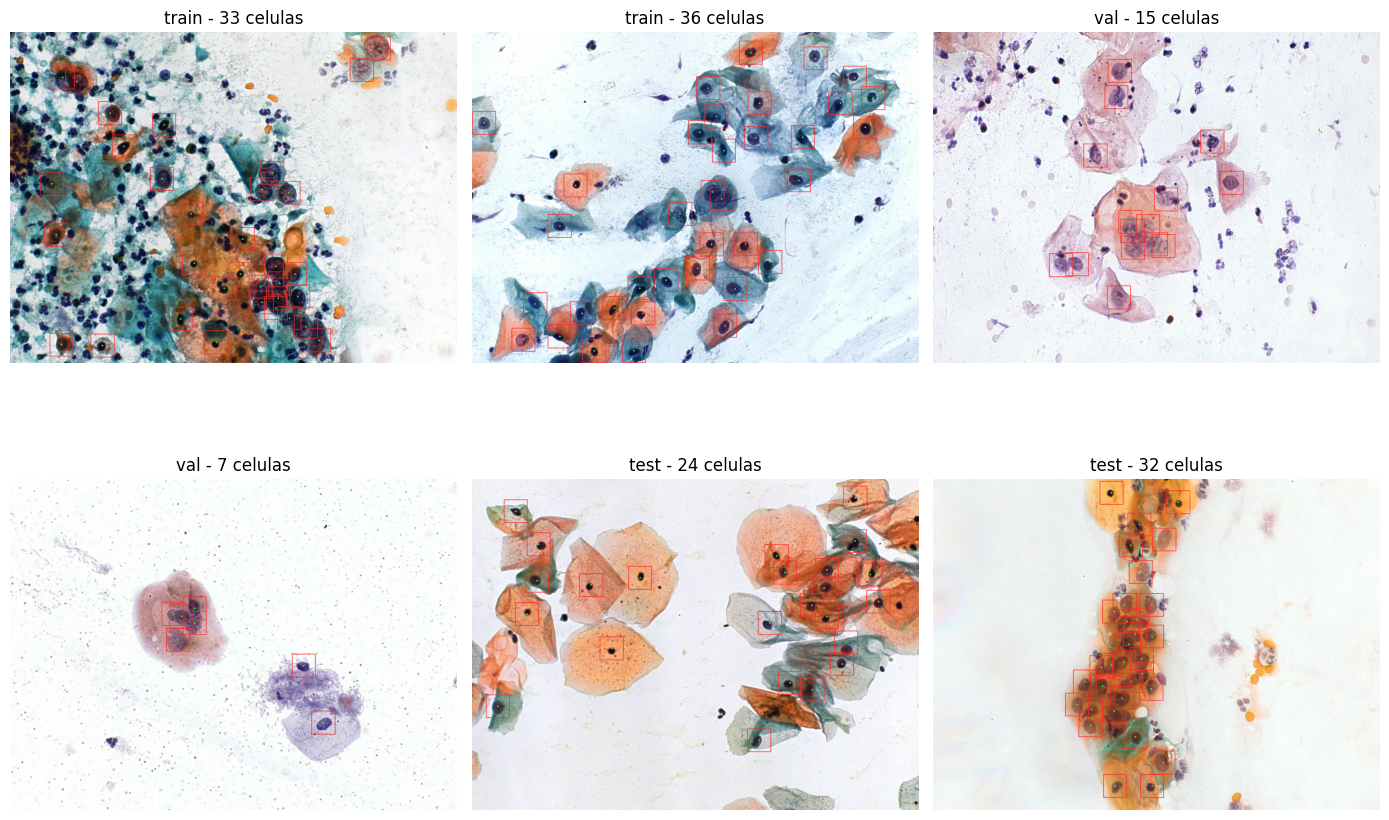

In [ ]:
def draw_yolo_labels(image_path: Path, label_path: Path, max_boxes=250):
    im = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(im)
    w, h = im.size
    lines = label_path.read_text().strip().splitlines() if label_path.exists() else []
    for line in lines[:max_boxes]:
        cls, xc, yc, bw, bh = map(float, line.split())
        x1 = (xc - bw / 2) * w
        y1 = (yc - bh / 2) * h
        x2 = (xc + bw / 2) * w
        y2 = (yc + bh / 2) * h
        draw.rectangle([x1, y1, x2, y2], outline=(255, 40, 40), width=2)
        draw.ellipse([(xc*w)-2, (yc*h)-2, (xc*w)+2, (yc*h)+2], fill=(30, 255, 80))
    return im

sample_paths = []
for split in ["train", "val", "test"]:
    imgs = sorted((cfg.YOLO_DIR / "images" / split).glob("*.png"))
    sample_paths.extend(random.sample(imgs, k=min(2, len(imgs))))

plt.figure(figsize=(14, 10))
for i, img_path in enumerate(sample_paths[:6], 1):
    label_path = cfg.YOLO_DIR / "labels" / img_path.parent.name / f"{img_path.stem}.txt"
    im = draw_yolo_labels(img_path, label_path)
    plt.subplot(2, 3, i)
    plt.imshow(im)
    plt.title(f"{img_path.parent.name} - {len(label_path.read_text().splitlines())} celulas")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Treinar YOLO11 com fallback para T4

O notebook tenta `yolo11m.pt` em 1024 px. Se der erro de memoria, ele limpa CUDA e tenta configuracoes menores automaticamente.

In [ ]:
def train_with_fallback(cfg: CFG, data_yaml: Path):
    attempts = list(cfg.TRAIN_ATTEMPTS)
    # Nao usamos batch=-1 aqui: no T4 o AutoBatch pode testar uma opcao grande, acusar OOM
    # e escolher batch 2, que subutiliza a GPU e multiplica os steps por epoca.

    last_error = None
    for attempt_id, attempt in enumerate(attempts, start=1):
        print("\n" + "=" * 90)
        print(f"Tentativa {attempt_id}/{len(attempts)}: {attempt}")
        print(f"Steps/epoca estimados: {math.ceil(summary.loc['train', 'images'] / attempt['batch'])}")
        print("=" * 90)
        try:
            torch.cuda.empty_cache()
            model = YOLO(attempt["model"])
            results = model.train(
                data=str(data_yaml),
                project=str(cfg.RUNS_DIR),
                name=f"{cfg.EXPERIMENT_NAME}_{Path(attempt['model']).stem}_{attempt['imgsz']}",
                epochs=cfg.EPOCHS,
                patience=cfg.PATIENCE,
                imgsz=attempt["imgsz"],
                batch=attempt["batch"],
                device=cfg.DEVICE if torch.cuda.is_available() else "cpu",
                workers=cfg.WORKERS,
                pretrained=True,
                optimizer="AdamW",
                lr0=0.002,
                lrf=0.01,
                momentum=0.937,
                weight_decay=0.0005,
                warmup_epochs=5,
                cos_lr=True,
                amp=True,
                cache=True,
                seed=cfg.SEED,
                deterministic=False,
                single_cls=True,
                plots=False,
                save=True,
                save_period=25,
                exist_ok=True,
                close_mosaic=25,
                # Aumentos adequados para microscopia: rotacoes/flips sao validos e ajudam bastante.
                hsv_h=0.015,
                hsv_s=0.45,
                hsv_v=0.25,
                degrees=180.0,
                translate=0.10,
                scale=0.35,
                shear=3.0,
                perspective=0.0005,
                fliplr=0.50,
                flipud=0.50,
                mosaic=0.60,
                mixup=0.08,
                erasing=0.15,
                box=8.0,
                cls=0.25,
                dfl=1.5,
                nbs=64,
            )
            save_dir = Path(results.save_dir)
            best = save_dir / "weights" / "best.pt"
            if not best.exists():
                raise FileNotFoundError(f"best.pt nao encontrado em {best}")
            print(f"Treino concluido. Best: {best}")
            return model, best, save_dir, attempt
        except RuntimeError as e:
            last_error = e
            msg = str(e).lower()
            print(f"Falha na tentativa {attempt_id}: {e}")
            if "out of memory" in msg or "cuda" in msg:
                try:
                    del model
                except Exception:
                    pass
                gc.collect()
                torch.cuda.empty_cache()
                continue
            raise
    raise RuntimeError(f"Todas as tentativas falharam. Ultimo erro: {last_error}")

trained_model, best_weights, train_dir, train_attempt = train_with_fallback(cfg, data_yaml)
print("Melhor peso:", best_weights)
print("Pasta do treino:", train_dir)
print("Config usada:", train_attempt)


Tentativa 1/5: {'model': 'yolo11s.pt', 'imgsz': 960, 'batch': 12}
Steps/epoca estimados: 27
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=8.0, cache=True, cfg=None, classes=None, close_mosaic=25, cls=0.25, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/cric_cell_detection/yolo_dataset/data.yaml, degrees=180.0, deterministic=False, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=260, erasing=0.15, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.45, hsv_v=0.25, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.08, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.6, multi

## 8. Validar, testar e salvar metricas

A validacao usa `augment=True` para TTA na avaliacao, o que costuma ajudar em imagens microscopicas com orientacao livre.

In [ ]:
best_model = YOLO(str(best_weights))
val_imgsz = train_attempt["imgsz"]

val_metrics = best_model.val(
    data=str(data_yaml),
    split="val",
    imgsz=val_imgsz,
    batch=max(1, train_attempt["batch"] if isinstance(train_attempt["batch"], int) and train_attempt["batch"] > 0 else 8),
    device=cfg.DEVICE if torch.cuda.is_available() else "cpu",
    workers=cfg.WORKERS,
    conf=0.001,
    iou=0.70,
    max_det=cfg.MAX_DET,
    augment=True,
    single_cls=True,
    plots=False,
    project=str(cfg.RUNS_DIR),
    name="val_tta",
    exist_ok=True,
)

test_metrics = best_model.val(
    data=str(data_yaml),
    split="test",
    imgsz=val_imgsz,
    batch=max(1, train_attempt["batch"] if isinstance(train_attempt["batch"], int) and train_attempt["batch"] > 0 else 8),
    device=cfg.DEVICE if torch.cuda.is_available() else "cpu",
    workers=cfg.WORKERS,
    conf=0.001,
    iou=0.70,
    max_det=cfg.MAX_DET,
    augment=True,
    single_cls=True,
    plots=False,
    project=str(cfg.RUNS_DIR),
    name="test_tta",
    exist_ok=True,
)

metrics_payload = {
    "best_weights": str(best_weights),
    "train_dir": str(train_dir),
    "train_attempt": train_attempt,
    "box_size_px": cfg.BOX_SIZE_PX,
    "val_map50": float(val_metrics.box.map50),
    "val_map50_95": float(val_metrics.box.map),
    "test_map50": float(test_metrics.box.map50),
    "test_map50_95": float(test_metrics.box.map),
}
metrics_path = cfg.WORK_DIR / "metrics_summary.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2), encoding="utf-8")
print(json.dumps(metrics_payload, indent=2))

NameError: name 'YOLO' is not defined

## 9. Inferencia em todas as imagens e CSV de celulas detectadas

Esta etapa roda o melhor modelo em todas as imagens originais, salva imagens anotadas, `.txt` YOLO e um CSV com cada celula detectada.

In [ ]:
predict_dir = cfg.WORK_DIR / "predictions"
results = best_model.predict(
    source=str(images_dir),
    imgsz=val_imgsz,
    conf=cfg.PRED_CONF,
    iou=cfg.PRED_IOU,
    max_det=cfg.MAX_DET,
    device=cfg.DEVICE if torch.cuda.is_available() else "cpu",
    augment=True,
    save=True,
    save_txt=True,
    save_conf=True,
    project=str(predict_dir),
    name="all_images_tta",
    exist_ok=True,
    stream=False,
)

rows = []
for r in results:
    image_name = Path(r.path).name
    if r.boxes is None or len(r.boxes) == 0:
        continue
    xyxy = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()
    for i, (box, conf) in enumerate(zip(xyxy, confs), start=1):
        x1, y1, x2, y2 = box.tolist()
        rows.append({
            "image": image_name,
            "det_id": i,
            "class_id": 0,
            "class_name": "cell",
            "confidence": float(conf),
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "x_center": float((x1 + x2) / 2),
            "y_center": float((y1 + y2) / 2),
            "width": float(x2 - x1),
            "height": float(y2 - y1),
        })

pred_df = pd.DataFrame(rows)
pred_csv = cfg.WORK_DIR / "predicted_cells.csv"
pred_df.to_csv(pred_csv, index=False)
print(f"Deteccoes salvas em: {pred_csv}")
print(f"Imagens anotadas em: {predict_dir / 'all_images_tta'}")
display(pred_df.head())
print("Total de celulas detectadas:", len(pred_df))

## 10. Visualizar inferencias

Amostras aleatorias das imagens salvas pelo YOLO.

In [ ]:
pred_images = sorted((predict_dir / "all_images_tta").glob("*.jpg")) + sorted((predict_dir / "all_images_tta").glob("*.png"))
if not pred_images:
    print("Nenhuma imagem de predicao encontrada.")
else:
    samples = random.sample(pred_images, k=min(6, len(pred_images)))
    plt.figure(figsize=(14, 10))
    for i, p in enumerate(samples, 1):
        im = Image.open(p).convert("RGB")
        plt.subplot(2, 3, i)
        plt.imshow(im)
        plt.title(p.name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

## 11. Exportar artefatos para o Drive

Salva pesos, metricas, dataset convertido e predicoes em um `.zip` no Drive.

In [ ]:
export_root = Path("/content/drive/MyDrive/CRIC/cric_cell_detection_outputs")
export_root.mkdir(parents=True, exist_ok=True)

# Copias diretas dos artefatos mais importantes.
shutil.copy2(best_weights, export_root / "best_cell_detector.pt")
shutil.copy2(cfg.WORK_DIR / "metrics_summary.json", export_root / "metrics_summary.json")
shutil.copy2(cfg.WORK_DIR / "predicted_cells.csv", export_root / "predicted_cells.csv")
shutil.copy2(data_yaml, export_root / "data.yaml")

zip_base = str(export_root / "cric_cell_detection_full_artifacts")
zip_path = shutil.make_archive(zip_base, "zip", root_dir=str(cfg.WORK_DIR))
print(f"Artefatos principais salvos em: {export_root}")
print(f"Pacote completo: {zip_path}")

## Observacoes praticas

- Se as caixas da auditoria visual nao cobrem o alvo desejado, rode novamente com `BOX_SIZE_PX` entre `56` e `96`.
- Para maior mAP com mais tempo de GPU, aumente `EPOCHS` para `350` e adicione uma tentativa `{"model": "yolo11m.pt", "imgsz": 1024, "batch": 6}` ou `{"model": "yolo11l.pt", "imgsz": 768, "batch": 4}` em `TRAIN_ATTEMPTS`.
- Para inferencia mais conservadora, aumente `PRED_CONF`; para marcar mais celulas, reduza para `0.08` ou `0.10`.
- O mAP medido aqui e contra caixas artificiais criadas dos pontos de nucleo, porque o CRIC Classification nao fornece bounding boxes reais.